# Milan Cross-Comparison Start
This notebook sets up a first cross-comparison between Airbnb activity and long-term rental levels in Milan. The goal is to build a clean base table and produce one generic visualization to guide deeper analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## Load Datasets
We use three sources: cleaned Airbnb listings, Airbnb reviews with dates, and OMI rental quotations.

In [2]:
listings = pd.read_csv('Data/listings_milan_clean.csv')
reviews = pd.read_csv('Data/reviews_milan.csv')
rentals = pd.read_csv('Data/total_rentals.csv', sep=';')

print('Listings shape:', listings.shape)
print('Reviews shape:', reviews.shape)
print('Rentals shape:', rentals.shape)

Listings shape: (20357, 25)
Reviews shape: (981739, 2)
Rentals shape: (6729, 20)


## Build Comparable Yearly Indicators
We create yearly Airbnb activity from reviews and yearly rental level from OMI values, then merge on Year.

In [3]:
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')
reviews['Year'] = reviews['date'].dt.year

airbnb_yearly = (
    reviews.dropna(subset=['Year'])
    .groupby('Year')
    .agg(review_count=('listing_id', 'size'), active_listings=('listing_id', 'nunique'))
    .reset_index()
)

for col in ['Loc_min', 'Loc_max']:
    rentals[col] = pd.to_numeric(
        rentals[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

rentals['Year'] = pd.to_numeric(rentals['Year'], errors='coerce')
rentals['rent_mid'] = (rentals['Loc_min'] + rentals['Loc_max']) / 2

rentals_yearly = (
    rentals.dropna(subset=['Year', 'rent_mid'])
    .groupby('Year', as_index=False)['rent_mid']
    .mean()
)

comparison = airbnb_yearly.merge(rentals_yearly, on='Year', how='inner').sort_values('Year')
comparison.head()

,Year,review_count,active_listings,rent_mid
0,2018,40521,1991,10.572747
1,2019,56955,2712,10.985507
2,2020,18498,2437,11.197479
3,2021,40071,3344,11.308796
4,2022,110767,5649,12.044856


## Generic Visualization
Before plotting, we standardize the yearly Airbnb and rent indicators with a z-score so they can be compared on the same scale. For each metric $x$, the standardized value is computed as $z = (x - \mu)/\sigma$, where $\mu$ is the mean across years and $\sigma$ is the standard deviation across years.
The first view compares these standardized trends and includes a simple scatter to inspect the relationship between Airbnb activity and average rent level.

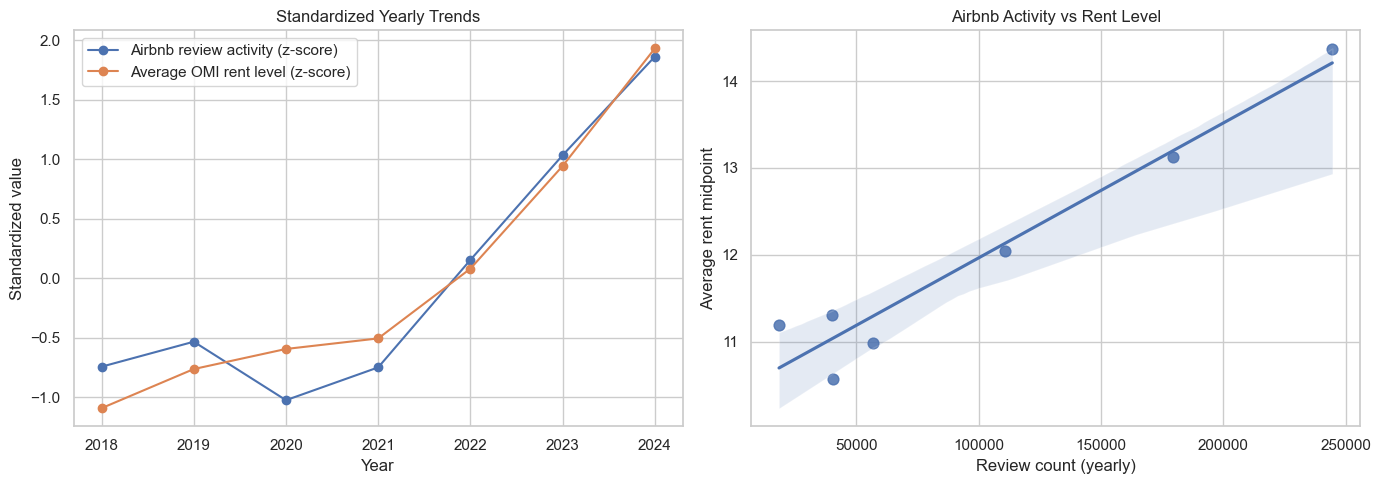

In [4]:
viz = comparison.copy()
viz['reviews_z'] = (viz['review_count'] - viz['review_count'].mean()) / viz['review_count'].std(ddof=0)
viz['rent_z'] = (viz['rent_mid'] - viz['rent_mid'].mean()) / viz['rent_mid'].std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(viz['Year'], viz['reviews_z'], marker='o', label='Airbnb review activity (z-score)')
axes[0].plot(viz['Year'], viz['rent_z'], marker='o', label='Average OMI rent level (z-score)')
axes[0].set_title('Standardized Yearly Trends')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Standardized value')
axes[0].legend()

sns.regplot(data=viz, x='review_count', y='rent_mid', ax=axes[1], scatter_kws={'s': 60, 'alpha': 0.85})
axes[1].set_title('Airbnb Activity vs Rent Level')
axes[1].set_xlabel('Review count (yearly)')
axes[1].set_ylabel('Average rent midpoint')

plt.tight_layout()
plt.show()

## Comments on the First Plot
Metric meaning: `review_count` is the total number of Airbnb reviews observed in a given year (used here as a proxy for platform activity). `rent_mid` is the midpoint between `Loc_min` and `Loc_max` from OMI data, then averaged across zones for each year (proxy for yearly rent level). `reviews_z` and `rent_z` are standardized versions of these two yearly metrics, computed as z-scores to compare movements on the same vertical scale.
From the output, both standardized lines increase strongly after 2021 and are very close in 2022-2024, which suggests recent co-movement between Airbnb activity and average rent level. Earlier years show partial divergence, especially around 2019-2021, so the relationship appears time-varying rather than constant.
In the scatter panel, the regression line is clearly positive, meaning years with higher `review_count` are associated with higher `rent_mid` in this aggregated view. This supports an exploratory association, but does not establish causality.

## Comments on the Second Plot
Metric meaning: `active_listings` counts unique listing IDs with at least one review in that year. `reviews_per_active_listing` is `review_count / active_listings`, so it measures average review intensity per active listing.
From the output, `active_listings` grows markedly from 2021 onward, while `reviews_per_active_listing` drops sharply in 2020, recovers in 2021-2023, and softens slightly in 2024. This pattern suggests that market expansion (more active listings) and engagement intensity per listing do not move identically across all years.

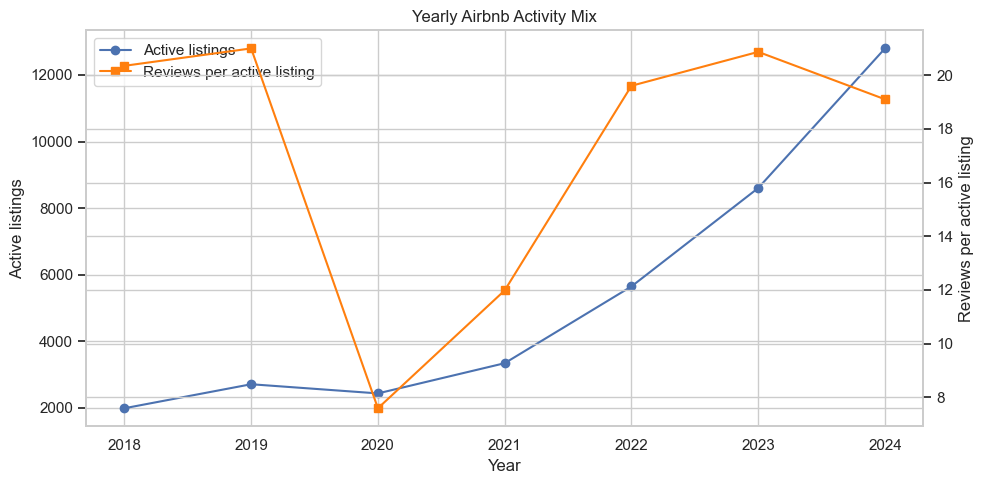

In [5]:
mix = comparison.copy()
mix['reviews_per_active_listing'] = mix['review_count'] / mix['active_listings'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mix['Year'], mix['active_listings'], marker='o', label='Active listings')
ax2 = ax.twinx()
ax2.plot(mix['Year'], mix['reviews_per_active_listing'], marker='s', color='tab:orange', label='Reviews per active listing')

ax.set_title('Yearly Airbnb Activity Mix')
ax.set_xlabel('Year')
ax.set_ylabel('Active listings')
ax2.set_ylabel('Reviews per active listing')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

## Rent Levels vs Review Activity
This plot compares yearly Airbnb review activity with each rent metric from OMI: lower bound (`Loc_min`), midpoint (`rent_mid`), and upper bound (`Loc_max`).

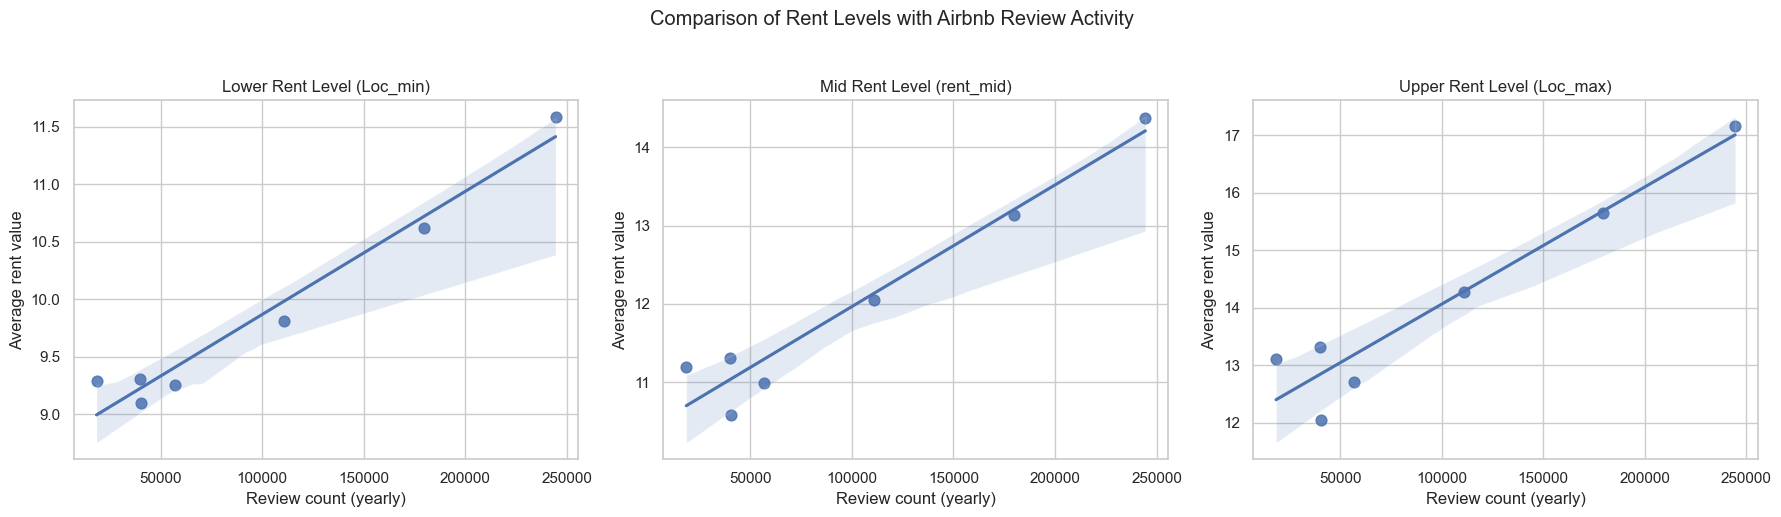

In [6]:
rent_levels_yearly = (
    rentals.dropna(subset=['Year', 'Loc_min', 'Loc_max'])
    .groupby('Year', as_index=False)
    .agg(
        Loc_min=('Loc_min', 'mean'),
        Loc_max=('Loc_max', 'mean')
    )
)
rent_levels_yearly['rent_mid'] = (rent_levels_yearly['Loc_min'] + rent_levels_yearly['Loc_max']) / 2

rent_vs_reviews = airbnb_yearly.merge(rent_levels_yearly, on='Year', how='inner').sort_values('Year')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
metrics = ['Loc_min', 'rent_mid', 'Loc_max']
titles = ['Lower Rent Level (Loc_min)', 'Mid Rent Level (rent_mid)', 'Upper Rent Level (Loc_max)']

for ax, metric, title in zip(axes, metrics, titles):
    sns.regplot(
        data=rent_vs_reviews,
        x='review_count',
        y=metric,
        ax=ax,
        scatter_kws={'s': 60, 'alpha': 0.85}
    )
    ax.set_title(title)
    ax.set_xlabel('Review count (yearly)')
    ax.set_ylabel('Average rent value')

fig.suptitle('Comparison of Rent Levels with Airbnb Review Activity', y=1.03)
plt.tight_layout()
plt.show()